## **Allocation of marks**

Stages 1,2,3   Total 30%

Ideally your dataset will not need a lot of work. Marks going for the choosing,  training, evaluation and refining of model primarily




---



Stage 4,5       Total 60%

Choose your model

https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html


Train and evaluate your model. Refine the model or choose another estimator or approach?

Do not overwrite cells and add commentry between iterations.



---




Stage 6         Total 10%

# **Stage 1**
***Describe Data***

 am using two datasets from Kaggle to predict how popular a song will be on Spotify.

**Dataset 1 - Spotify Tracks Dataset**
- Source: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
- Contains over 114,000 tracks with audio features like danceability, energy, tempo, loudness, etc.
- Each track has a popularity score from 0 to 100

**Dataset 2 - Billboard Hot 100**
- Source: https://www.kaggle.com/datasets/dhruvildave/billboard-the-hot-100-songs
- Contains songs that made it to the Billboard Hot 100 chart
- Includes peak position, weeks on chart, and chart date

**How I will link them:**
Both datasets have song name and artist name. I will merge them on these two columns to combine Spotify audio features with Billboard chart performance.

**Goal:** Predict a song's Spotify popularity score using its audio features and chart history.

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Datasets

In [6]:
df_spotify = pd.read_csv('dataset.csv')
df_spotify.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
df_billboard = pd.read_csv('charts.csv')
df_billboard.head()

,date,rank,song,artist,last-week,peak-rank,weeks-on-board
0,2021-11-06,1,Easy On Me,Adele,1.0,1,3
1,2021-11-06,2,Stay,The Kid LAROI & Justin Bieber,2.0,1,16
2,2021-11-06,3,Industry Baby,Lil Nas X & Jack Harlow,3.0,1,14
3,2021-11-06,4,Fancy Like,Walker Hayes,4.0,3,19
4,2021-11-06,5,Bad Habits,Ed Sheeran,5.0,2,18


### Explore the Spotify dataset

In [8]:
# Check what columns we have in Spotify dataset and their data types
print("Spotify columns:")
print(df_spotify.columns.tolist())
print()
print("Data types:")
print(df_spotify.dtypes)

Spotify columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Data types:
Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object


In [9]:
# Summary statistics of the Spotify data
df_spotify.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [10]:
# Check for missing values
print("Missing values in Spotify data:")
print(df_spotify.isnull().sum())

Missing values in Spotify data:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


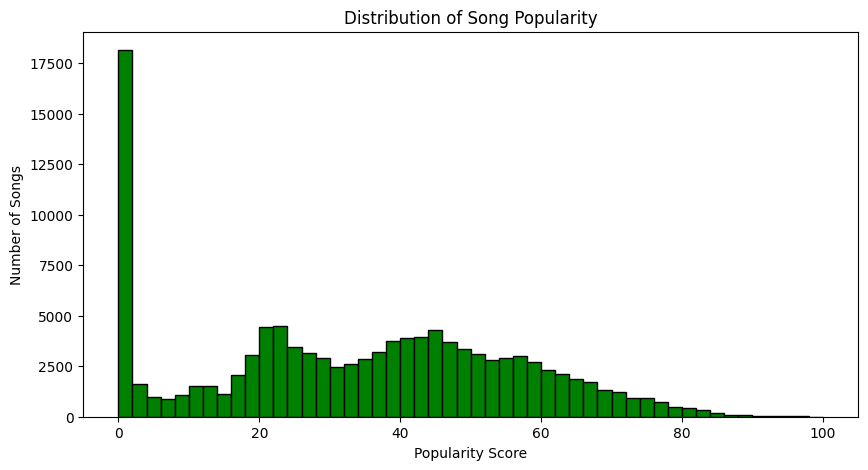

In [11]:
# Distribution of the popularity score
plt.figure(figsize=(10,5))
plt.hist(df_spotify['popularity'], bins=50, color='green', edgecolor='black')
plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Songs')
plt.show()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64


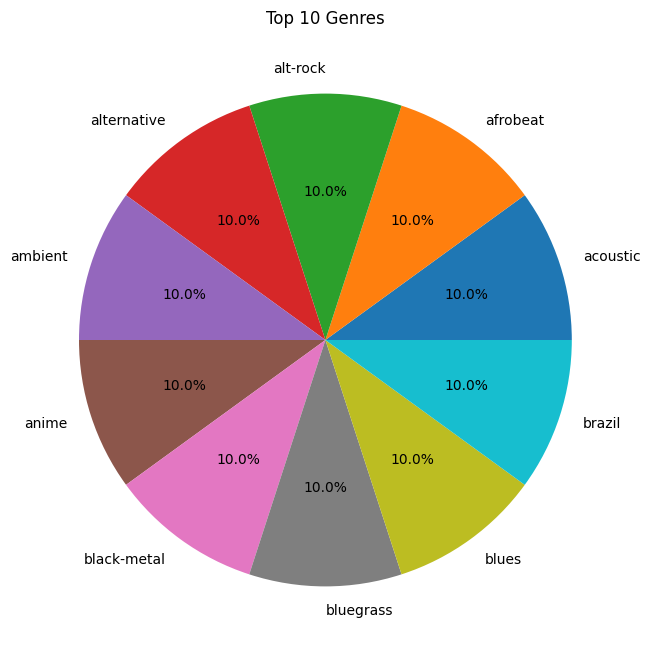

In [12]:
# Pie chart of track genres (top 10)
h = df_spotify['track_genre'].value_counts().head(10)
print(h)
h.plot(kind='pie', figsize=(8,8), autopct='%1.1f%%')
plt.title('Top 10 Genres')
plt.ylabel('')
plt.show()

###  Explore the Billboard dataset

In [13]:
# Check what columns we have in Billboard data and their data types
print("Billboard columns:")
print(df_billboard.columns.tolist())
print()
print("Data types:")
print(df_billboard.dtypes)

Billboard columns:
['date', 'rank', 'song', 'artist', 'last-week', 'peak-rank', 'weeks-on-board']

Data types:
date                  str
rank                int64
song                  str
artist                str
last-week         float64
peak-rank           int64
weeks-on-board      int64
dtype: object


In [14]:
# Summary statistics of Billboard data
df_billboard.describe()

,rank,last-week,peak-rank,weeks-on-board
count,330087.000000,297775.000000,330087.000000,330087.000000
mean,50.500929,47.591631,40.970629,9.161785
std,28.866094,28.054360,29.347481,7.618264
min,1.000000,1.000000,1.000000,1.000000
25%,26.000000,23.000000,13.000000,4.000000
50%,51.000000,47.000000,38.000000,7.000000
75%,76.000000,72.000000,65.000000,13.000000
max,100.000000,100.000000,100.000000,90.000000


In [15]:
# Check for missing values
print("Missing values in Billboard data:")
print(df_billboard.isnull().sum())

Missing values in Billboard data:
date                  0
rank                  0
song                  0
artist                0
last-week         32312
peak-rank             0
weeks-on-board        0
dtype: int64


# **Stage 2**

Justification for the property that you would like the model to predict.

**I want to predict the popularity score of a song.**

- Popularity is a number from 0 to 100, so it is a regression problem
- It is useful for artists and record labels to know what makes a song popular
- There are a lot of features to work with: danceability, energy, tempo, loudness, chart position etc.
- By combining Spotify audio features with Billboard chart data, we can see if chart performance helps predict popularity better than audio features alone

# **Stage 3**

Cleaning the data, linking datasets

First I need to clean both datasets, then merge them together on song name and artist.

In [17]:
# Clean the Spotify data
df_spotify_clean = df_spotify.copy()

# Make song names and artist names lowercase so they match better
df_spotify_clean['track_name_lower'] = df_spotify_clean['track_name'].astype(str).str.lower().str.strip()
df_spotify_clean['artist_lower'] = df_spotify_clean['artists'].astype(str).str.lower().str.strip()

df_spotify_clean.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_name_lower,artist_lower
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,comedy,gen hoshino
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,ghost - acoustic,ben woodward
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,to begin again,ingrid michaelson;zayn
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,can't help falling in love,kina grannis
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,hold on,chord overstreet


In [19]:
# Clean the Billboard data
df_billboard_clean = df_billboard.copy()

# Make song names and artist names lowercase
df_billboard_clean['track_name_lower'] = df_billboard_clean['song'].astype(str).str.lower().str.strip()
df_billboard_clean['artist_lower'] = df_billboard_clean['artist'].astype(str).str.lower().str.strip()

df_billboard_clean.head()

,date,rank,song,artist,last-week,peak-rank,weeks-on-board,track_name_lower,artist_lower
0,2021-11-06,1,Easy On Me,Adele,1.0,1,3,easy on me,adele
1,2021-11-06,2,Stay,The Kid LAROI & Justin Bieber,2.0,1,16,stay,the kid laroi & justin bieber
2,2021-11-06,3,Industry Baby,Lil Nas X & Jack Harlow,3.0,1,14,industry baby,lil nas x & jack harlow
3,2021-11-06,4,Fancy Like,Walker Hayes,4.0,3,19,fancy like,walker hayes
4,2021-11-06,5,Bad Habits,Ed Sheeran,5.0,2,18,bad habits,ed sheeran


In [20]:
# Billboard has multiple rows per song (one per week on chart)
# I want one row per song with: best (lowest) peak position and total weeks on chart

df_billboard_grouped = df_billboard_clean.groupby(['track_name_lower', 'artist_lower']).agg(
    peak_position=('peak-rank', 'min'),       
    weeks_on_chart=('weeks-on-board', 'max')   
).reset_index()

df_billboard_grouped.head()

,track_name_lower,artist_lower,peak_position,weeks_on_chart
0,"""b"" girls",young and restless,54,15
1,"""cherry cherry"" from hot august night",neil diamond,31,10
2,"""having a party"" medley",the ovations (featuring louis williams),56,9
3,"""joy"" pt. i",isaac hayes,30,9
4,"""roots"" medley",quincy jones,57,7


In [22]:
# Merge the two datasets on song name and artist and only keep songs that appear in both datasets
df_merged = pd.merge(df_spotify_clean, df_billboard_grouped, on=['track_name_lower', 'artist_lower'], how='inner' )

df_merged.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_name_lower,artist_lower,peak_position,weeks_on_chart
0,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.444,...,0.000000,0.0973,0.712,150.960,4,acoustic,i'm yours,jason mraz,6,76
1,11,5ivF4eQBqJiVL5IAE9jRyl,Jason Mraz,Love Is a Four Letter Word,I Won't Give Up,69,240165,False,0.483,0.303,...,0.000000,0.1150,0.139,133.406,3,acoustic,i won't give up,jason mraz,8,44
2,15,1KHdq8NK9QxnGjdXb55NiG,Landon Pigg,The Boy Who Never,Falling in Love at a Coffee Shop,58,244986,False,0.489,0.561,...,0.000046,0.1790,0.238,83.457,3,acoustic,falling in love at a coffee shop,landon pigg,93,2
3,20,3S0OXQeoh0w6AY8WQVckRW,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,75,242946,False,0.703,0.444,...,0.000000,0.0973,0.712,150.960,4,acoustic,i'm yours,jason mraz,6,76
4,27,0dzKBptH2P5j5a0MifBMwM,Jason Mraz,Feeling Good - Adult Pop Favorites,If It Kills Me,0,273653,False,0.633,0.429,...,0.000000,0.1320,0.520,143.793,4,acoustic,if it kills me,jason mraz,92,1


In [23]:
# Drop rows with missing values
df_merged = df_merged.dropna()
print("After dropping missing values:", df_merged.shape)

# Check the merged data
print("\nColumns in merged dataset:")
print(df_merged.columns.tolist())

After dropping missing values: (4685, 25)

Columns in merged dataset:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'track_name_lower', 'artist_lower', 'peak_position', 'weeks_on_chart']


In [25]:
# Select only the columns we need for the model
# These are the features (X) and what to predict (y)
feature_columns = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'peak_position', 'weeks_on_chart']

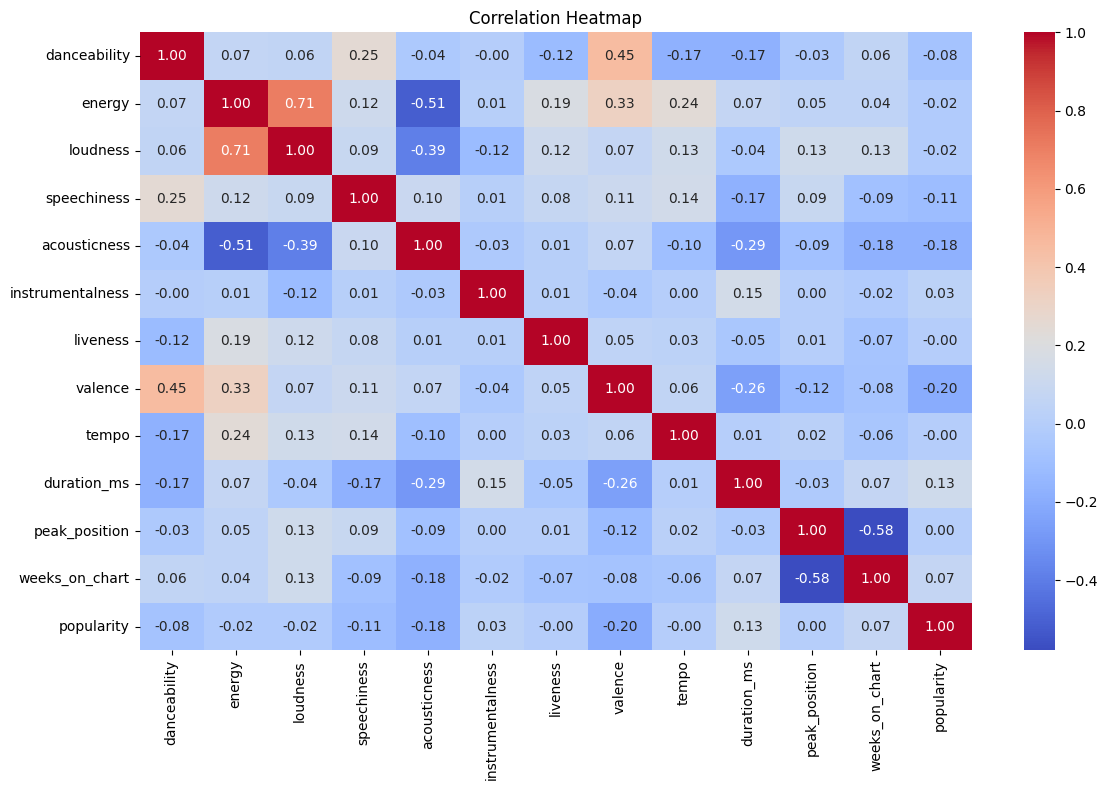

In [26]:
# Correlation heatmap to see which features relate to popularity
plt.figure(figsize=(12,8))
corr_cols = feature_columns + ['popularity']
corr = df_merged[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# **Stage 4**
Choose and train Estimator.

# **Stage 5**
Evaluate your model and revisit 4...repeat..

# **Stage 6**
***Present results and Conclusions***

